In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv("../data/processed/bank_churn_cleaned.csv")

In [4]:
df.head()

,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,hascrcard,is_active_member,estimated_salary,exited,age_group,salary_band,balance_group,churn_status,activity_status
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,High,Low,Churned,Active
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,High,Medium,Retained,Active
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,High,Very High,Churned,Inactive
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,Medium,Low,Retained,Inactive
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,Medium,High,Retained,Active


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   surname           10000 non-null  str    
 2   credit_score      10000 non-null  int64  
 3   geography         10000 non-null  str    
 4   gender            10000 non-null  str    
 5   age               10000 non-null  int64  
 6   tenure            10000 non-null  int64  
 7   balance           10000 non-null  float64
 8   num_of_products   10000 non-null  int64  
 9   hascrcard         10000 non-null  int64  
 10  is_active_member  10000 non-null  int64  
 11  estimated_salary  10000 non-null  float64
 12  exited            10000 non-null  int64  
 13  age_group         9978 non-null   str    
 14  salary_band       10000 non-null  str    
 15  balance_group     10000 non-null  str    
 16  churn_status      10000 non-null  str    
 17  activ

In [6]:
df.columns

Index(['customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'hascrcard', 'is_active_member',
       'estimated_salary', 'exited', 'age_group', 'salary_band',
       'balance_group', 'churn_status', 'activity_status'],
      dtype='str')

# Customer Churn Distribution

Analyzing the overall churn distribution to understand customer retention performance.

In [7]:
df['churn_status'].value_counts()

churn_status
Retained    7963
Churned     2037
Name: count, dtype: int64

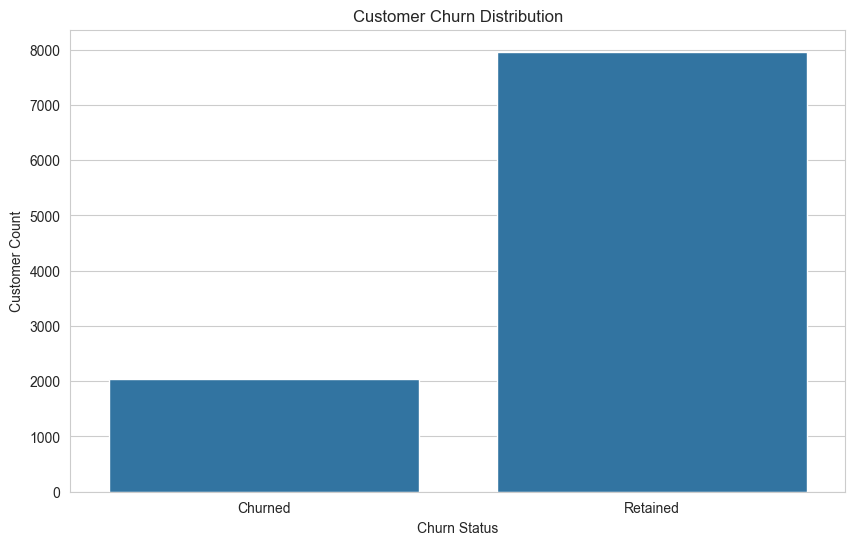

In [8]:
sns.countplot(
    x='churn_status',
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

plt.show()

In [9]:
churn_rate = df['exited'].mean() * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


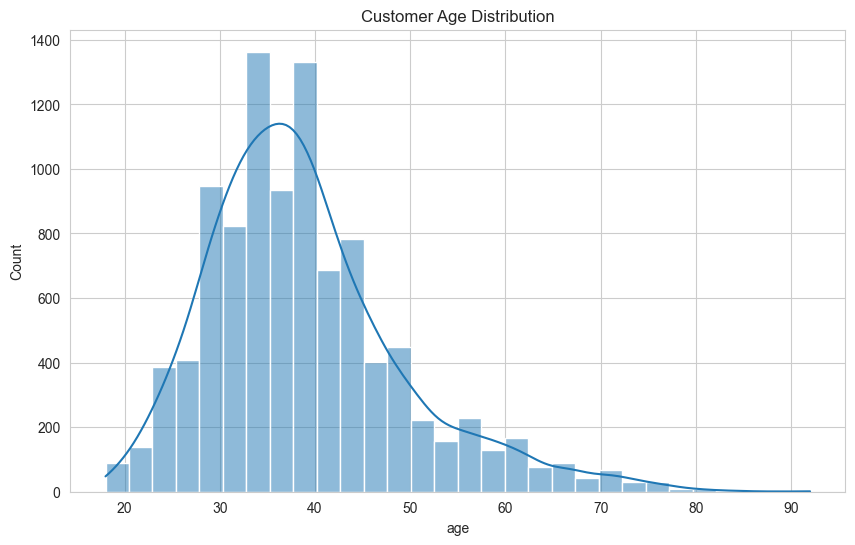

In [10]:
sns.histplot(
    data=df,
    x='age',
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")

plt.show()

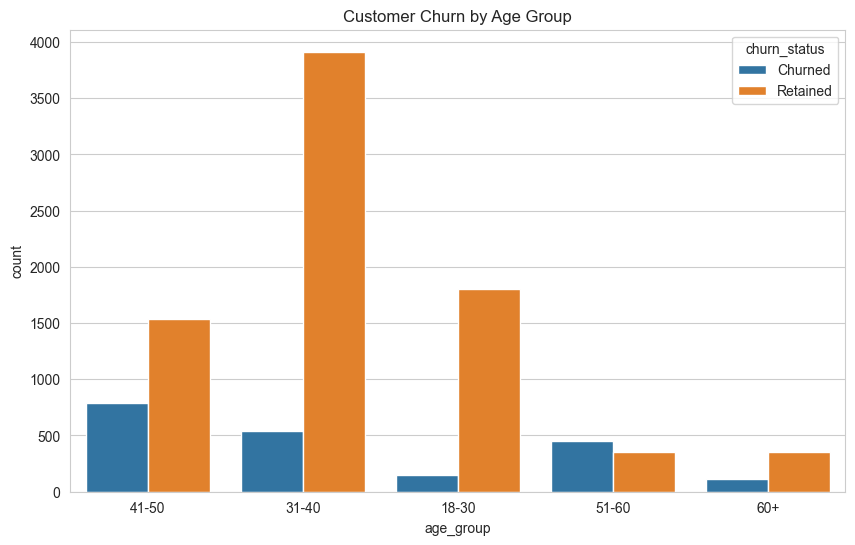

In [11]:
sns.countplot(
    x='age_group',
    hue='churn_status',
    data=df
)

plt.title("Customer Churn by Age Group")

plt.show()

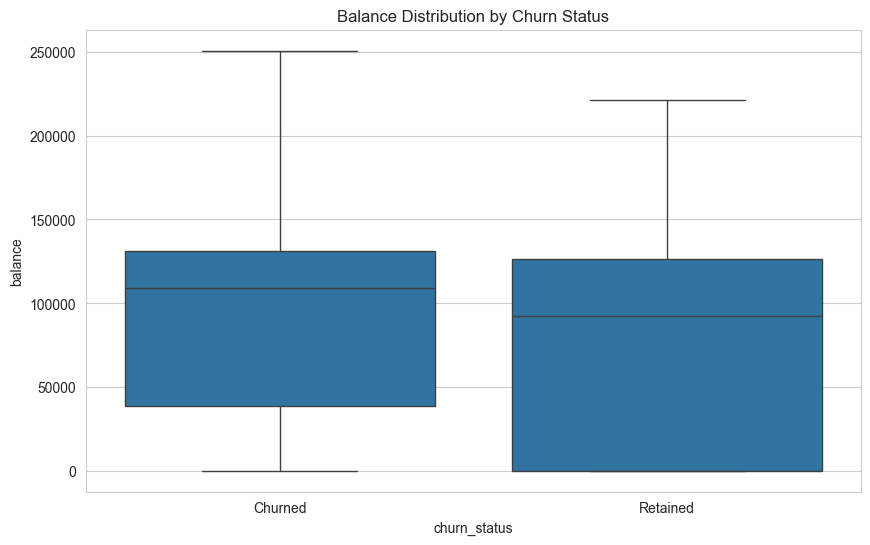

In [12]:
sns.boxplot(
    x='churn_status',
    y='balance',
    data=df
)

plt.title("Balance Distribution by Churn Status")

plt.show()

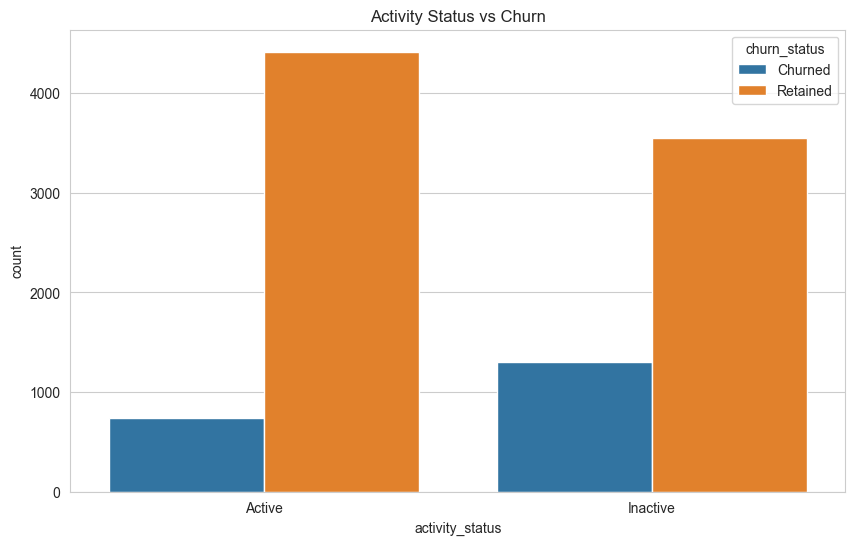

In [13]:
sns.countplot(
    x='activity_status',
    hue='churn_status',
    data=df
)

plt.title("Activity Status vs Churn")

plt.show()

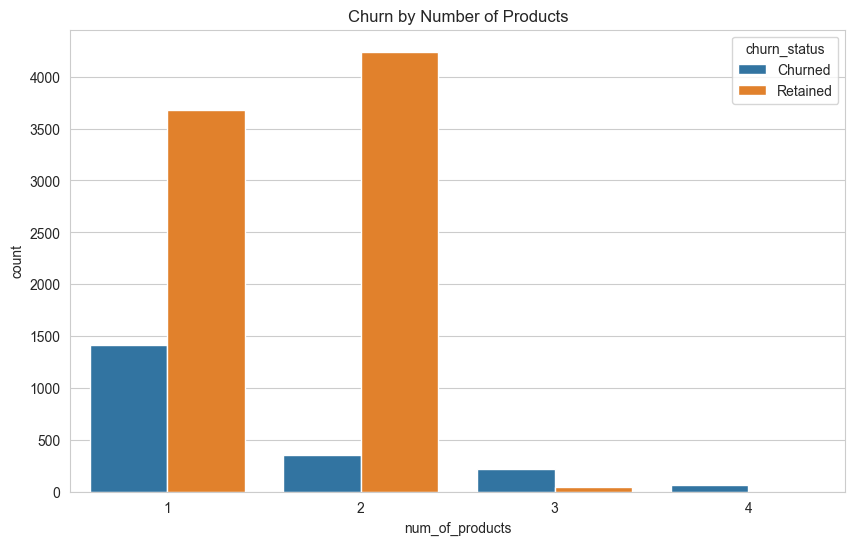

In [14]:
sns.countplot(
    x='num_of_products',
    hue='churn_status',
    data=df
)

plt.title("Churn by Number of Products")

plt.show()

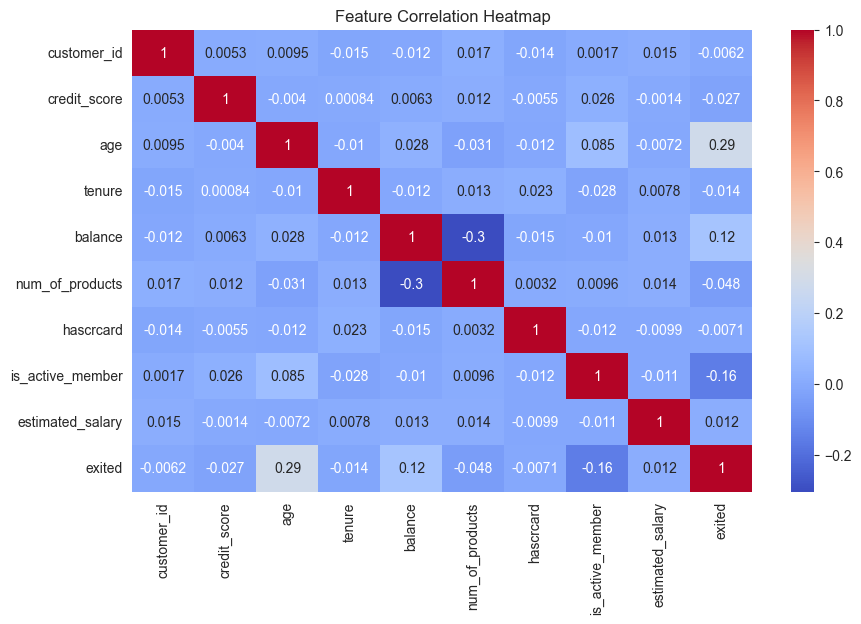

In [15]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Key Business Findings

### Key Insights

- Customer churn exists across multiple demographic and financial segments.
- Age appears to influence churn behavior significantly.
- Inactive customers demonstrate higher churn tendencies.
- Customer engagement through multiple products may improve retention.
- Financial indicators such as balance may correlate with churn risk.

In [16]:
df.columns

Index(['customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'hascrcard', 'is_active_member',
       'estimated_salary', 'exited', 'age_group', 'salary_band',
       'balance_group', 'churn_status', 'activity_status'],
      dtype='str')

In [17]:
df.rename(columns={
    'hascrcard': 'has_cr_card'
}, inplace=True)

In [18]:
df.drop(columns=['surname'], inplace=True)

In [19]:
df.columns

Index(['customer_id', 'credit_score', 'geography', 'gender', 'age', 'tenure',
       'balance', 'num_of_products', 'has_cr_card', 'is_active_member',
       'estimated_salary', 'exited', 'age_group', 'salary_band',
       'balance_group', 'churn_status', 'activity_status'],
      dtype='str')

In [20]:
df.to_csv("../data/processed/bank_churn_cleaned.csv", index=False)